# Food Delivery — AI Agent Demo Notebook

**Databases Course — Final Project**

This notebook demonstrates the full system end-to-end:
1. Connect to the MySQL database
2. Run SQL queries directly (sanity checks)
3. Run the analytical **VIEWs** that answer our 4 problems
4. Run the **STORED PROCEDURES**
5. Visualize a few key insights with matplotlib
6. **AI agent** — ask natural-language questions, get SQL-grounded answers

> **Before running:** make sure you have run `01_schema.sql`, then `etl_load.py`, then `02_views_procedures.sql`. See README.md.

## 1. Setup — load environment and connect to MySQL

In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

# Load credentials from .env
load_dotenv()

DB_HOST = os.getenv('DB_HOST', 'localhost')
DB_PORT = os.getenv('DB_PORT', '3306')
DB_USER = os.getenv('DB_USER', 'root')
DB_PASSWORD = os.getenv('DB_PASSWORD', '')
DB_NAME = os.getenv('DB_NAME', 'food_delivery')

# SQLAlchemy URI (works for both pymysql and mysql-connector)
DB_URI = f'mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'

engine = create_engine(DB_URI)
print('✅ engine created — testing connection...')

with engine.connect() as conn:
    result = conn.execute(text('SELECT VERSION()')).fetchone()
    print(f'connected to MySQL {result[0]}')

✅ engine created — testing connection...
connected to MySQL 8.0.44


### Sanity check — list tables and row counts

In [2]:
tables = ['locations', 'cuisines', 'routes', 'restaurants',
          'customers', 'orders', 'order_items', 'deliveries', 'feedback']

rows = []
with engine.connect() as conn:
    for t in tables:
        n = conn.execute(text(f'SELECT COUNT(*) FROM {t}')).scalar()
        rows.append({'table': t, 'rows': n})

pd.DataFrame(rows)

,table,rows
0,locations,10
1,cuisines,5
2,routes,5
3,restaurants,100
4,customers,20000
5,orders,20000
6,order_items,20000
7,deliveries,20000
8,feedback,20000


## 2. Direct SQL queries — exploratory checks

Quick joins and aggregations to verify the schema is healthy.

In [3]:
# Top 5 cities by total revenue
q = '''
    SELECT loc.city,
           COUNT(o.order_id)            AS n_orders,
           ROUND(SUM(o.order_value),2)  AS total_revenue,
           ROUND(AVG(o.order_value),2)  AS avg_order_value
    FROM orders o
    JOIN customers c   ON o.customer_id = c.customer_id
    JOIN locations loc ON c.location_id = loc.location_id
    GROUP BY loc.city
    ORDER BY total_revenue DESC
'''
df_cities = pd.read_sql(q, engine)
df_cities

,city,n_orders,total_revenue,avg_order_value
0,Ahmedabad,2051,56309.36,27.45
1,Jaipur,2013,55720.76,27.68
2,Pune,2026,55286.24,27.29
3,Kolkata,2032,55277.67,27.20
4,Delhi,2027,55041.43,27.15
5,Hyderabad,1973,54842.44,27.80
6,Mumbai,1980,54644.66,27.60
7,Bangalore,1968,53859.76,27.37
8,Chennai,1998,53535.69,26.79
9,Lucknow,1932,52183.79,27.01


In [4]:
# Average delivery delay by traffic condition
q = '''
    SELECT traffic_condition,
           COUNT(*)                       AS n,
           ROUND(AVG(delivery_delay),2)   AS avg_delay_min
    FROM deliveries
    GROUP BY traffic_condition
    ORDER BY avg_delay_min DESC
'''
pd.read_sql(q, engine)

,traffic_condition,n,avg_delay_min
0,Low,6772,5.05
1,High,6528,4.98
2,Medium,6700,4.82


## 3. Analytical VIEWs — one per problem statement

Each of these answers one of the four problems from the project's problem statement.

### Problem 1 — Delay drivers

In [5]:
df = pd.read_sql('SELECT * FROM vw_delay_drivers LIMIT 15', engine)
df

,delivery_method,traffic_condition,weather_condition,n_orders,avg_delay_min,max_delay_min,avg_rating
0,Car,High,Rainy,706,5.93,19.88,2.99
1,Car,Low,Sunny,734,5.66,19.84,2.95
2,Car,Low,Snowy,772,5.54,19.92,3.17
3,Bike,Low,Snowy,756,5.47,19.80,3.01
4,Car,High,Sunny,656,5.33,19.99,3.13
5,Car,Medium,Sunny,702,5.33,19.99,2.95
6,Walk,High,Snowy,690,5.24,19.98,2.96
7,Bike,Low,Sunny,712,5.21,19.81,3.16
8,Bike,High,Sunny,774,5.05,20.00,2.92
9,Bike,Medium,Snowy,714,5.00,19.97,3.00


### Problem 2 — Route efficiency validity

In [6]:
df = pd.read_sql('SELECT * FROM vw_route_performance', engine)
df

,route_name,route_type,n_deliveries,avg_efficiency,avg_delay_min,avg_distance_km,avg_rating
0,Route_5,Car-only,4136,0.484,5.10,8.54,3.01
1,Route_2,Bike-friendly,3884,0.502,5.05,8.43,3.03
2,Route_4,Bike-friendly,3974,0.502,4.98,8.44,3.02
3,Route_1,Mixed,4114,0.500,4.85,8.62,3.05
4,Route_3,Bike-friendly,3892,0.493,4.78,8.46,3.02


### Problem 3 — Satisfaction drivers

In [7]:
df = pd.read_sql('SELECT * FROM vw_satisfaction_drivers', engine)
df

,food_temperature,food_condition,n_orders,avg_satisfaction,avg_rating,avg_freshness,avg_packaging
0,Warm,Good,2246,3.03,3.02,3.01,3.01
1,Warm,Poor,2112,3.03,3.01,2.98,3.00
2,Cold,Poor,2314,3.00,3.02,2.99,3.03
3,Hot,Fair,2350,2.98,3.09,3.07,3.00
4,Hot,Good,2190,2.98,3.00,2.96,3.01
5,Hot,Poor,2204,2.98,2.96,2.99,2.96
6,Cold,Good,2206,2.95,3.03,2.93,3.02
7,Cold,Fair,2136,2.95,3.06,3.00,2.96
8,Warm,Fair,2242,2.89,3.04,2.99,3.04


### Problem 4 — Loyalty programme ROI

In [8]:
df = pd.read_sql('SELECT * FROM vw_loyalty_analysis', engine)
df

,loyalty_program,n_customers,n_orders,avg_order_value,total_revenue,avg_rating,avg_order_history
0,0,9984,9984,27.27,272272.44,3.03,25.74
1,1,10016,10016,27.40,274429.36,3.02,25.76


## 4. Stored procedures

Parameterized analyses — one ID/argument in, structured rows out.

In [9]:
# A single restaurant's report card
with engine.connect() as conn:
    df = pd.read_sql(text('CALL sp_restaurant_report(1)'), conn)
df

,restaurant_id,n_orders,total_revenue,avg_order_value,avg_delay_min,avg_rating,avg_satisfaction
0,1,216,5803.48,26.87,5.22,3.02,3.31


In [10]:
# Top 10 most-ordered food items
with engine.connect() as conn:
    df = pd.read_sql(text('CALL sp_top_food_items(10)'), conn)
df

,food_item,n_orders,total_revenue,avg_order_value
0,Pasta,1884,52219.92,27.72
1,Whole cake,958,25825.66,26.96
2,Soup,948,25428.30,26.82
3,Cup cake,944,26358.26,27.92
4,Chicken rice,934,25862.46,27.69
5,Beef pie,934,25457.70,27.26
6,Cookie,930,25433.36,27.35
7,CoffeeBoba tea,922,25492.14,27.65
8,Chicken wings,918,24788.16,27.00
9,Pizza,916,25555.58,27.90


In [11]:
# Late deliveries (delay >= 15 min)
with engine.connect() as conn:
    df = pd.read_sql(text('CALL sp_late_deliveries(15)'), conn)
df.head()

,order_id,order_time,delivery_delay,traffic_condition,weather_condition,delivery_method,city,customer_rating
0,ORD019807,2024-03-11,20.0,High,Sunny,Walk,Mumbai,1
1,ORD016783,2024-11-25,20.0,High,Sunny,Bike,Bangalore,4
2,ORD013552,2024-10-12,20.0,High,Snowy,Car,Hyderabad,5
3,ORD012714,2024-03-08,20.0,High,Sunny,Bike,Delhi,5
4,ORD009807,2024-03-11,20.0,High,Sunny,Walk,Jaipur,1


## 5. Visualizations

Matplotlib charts to illustrate the four problems.

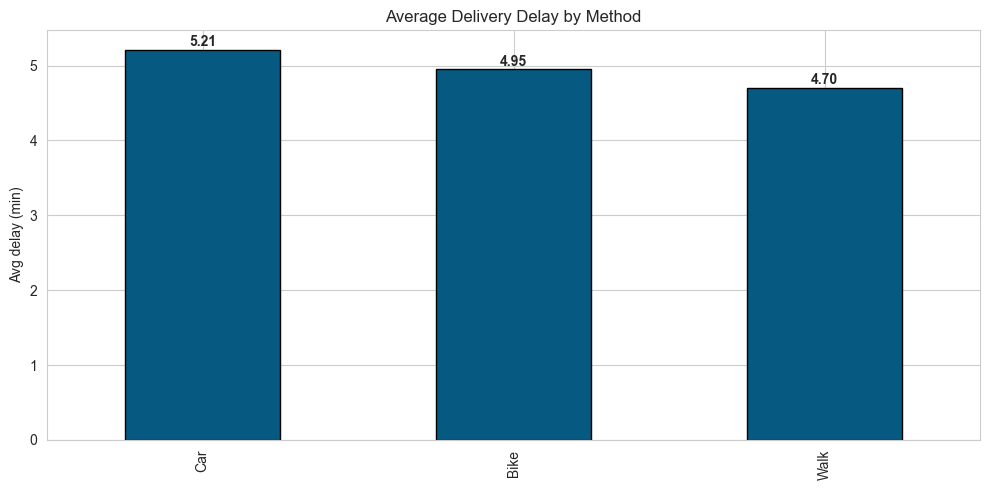

In [12]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# CHART 1 — average delay by delivery method
df = pd.read_sql('CALL sp_delivery_stats_by_method()', engine)
ax = df.plot(x='delivery_method', y='avg_delay_min', kind='bar',
             color='#065A82', legend=False, edgecolor='black')
ax.set_title('Average Delivery Delay by Method')
ax.set_ylabel('Avg delay (min)')
ax.set_xlabel('')
for i, v in enumerate(df['avg_delay_min']):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

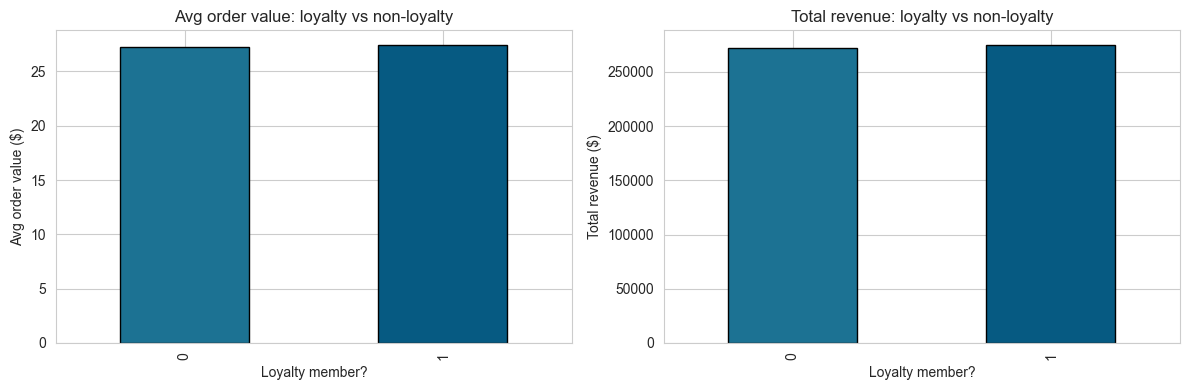

In [13]:
# CHART 2 — loyalty members vs non-members
df = pd.read_sql('SELECT * FROM vw_loyalty_analysis', engine)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.plot(x='loyalty_program', y='avg_order_value', kind='bar',
        ax=axes[0], color=['#1C7293', '#065A82'], legend=False, edgecolor='black')
axes[0].set_title('Avg order value: loyalty vs non-loyalty')
axes[0].set_ylabel('Avg order value ($)')
axes[0].set_xlabel('Loyalty member?')

df.plot(x='loyalty_program', y='total_revenue', kind='bar',
        ax=axes[1], color=['#1C7293', '#065A82'], legend=False, edgecolor='black')
axes[1].set_title('Total revenue: loyalty vs non-loyalty')
axes[1].set_ylabel('Total revenue ($)')
axes[1].set_xlabel('Loyalty member?')

plt.tight_layout()
plt.show()

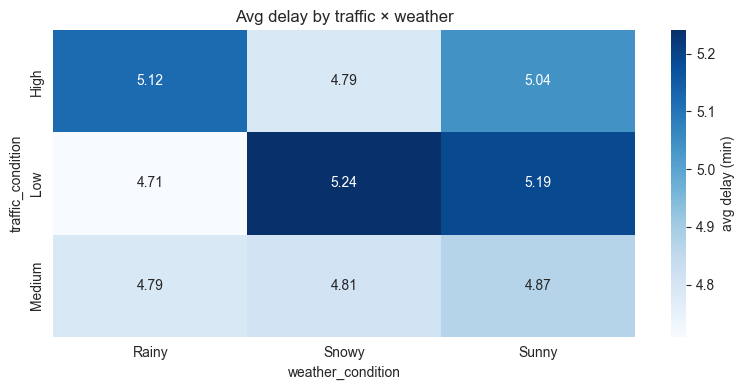

In [14]:
# CHART 3 — delay distribution by traffic condition (heatmap)
q = '''
    SELECT traffic_condition, weather_condition,
           ROUND(AVG(delivery_delay),2) AS avg_delay
    FROM deliveries
    GROUP BY traffic_condition, weather_condition
'''
df = pd.read_sql(q, engine)
pivot = df.pivot(index='traffic_condition', columns='weather_condition', values='avg_delay')

plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Blues', cbar_kws={'label': 'avg delay (min)'})
plt.title('Avg delay by traffic × weather')
plt.tight_layout()
plt.show()

## 6. AI Agent — natural language to SQL

Powered by **LangChain** + **Google Gemini**.

The agent introspects our schema and our 5 named views at runtime, plans a SQL query, executes it against MySQL, and explains the result.

> Make sure `GOOGLE_API_KEY` is set in your `.env`. Get a free key at https://aistudio.google.com/app/apikey

In [15]:
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits.sql.base import create_sql_agent
from langchain_community.agent_toolkits.sql.toolkit import SQLDatabaseToolkit
from langchain_google_genai import ChatGoogleGenerativeAI

GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY')
if not GOOGLE_API_KEY:
    raise RuntimeError('Set GOOGLE_API_KEY in your .env file before running this cell.')

# Wrap the database for LangChain
db = SQLDatabase.from_uri(DB_URI)
print('Tables visible to the agent:')
print(db.get_usable_table_names())

Tables visible to the agent:
['cuisines', 'customers', 'deliveries', 'feedback', 'locations', 'order_items', 'orders', 'restaurants', 'routes']


In [18]:
# Create the LLM — gemini-2.5-flash is fast and free-tier friendly
llm = ChatGoogleGenerativeAI(
    model='gemini-2.5-flash',
    google_api_key=GOOGLE_API_KEY,
    temperature=0,
)

toolkit = SQLDatabaseToolkit(db=db, llm=llm)

agent = create_sql_agent(
    llm=llm,
    toolkit=toolkit,
    verbose=True,
    handle_parsing_errors="Check the formatting and try again.",
    max_iterations=10,
    agent_type="tool-calling",
)
print('✅ agent ready')

✅ agent ready


### Demo questions — one per problem statement

Run these one at a time. The agent will print the SQL it generated, the rows it got back, and a natural-language summary.

In [19]:
# PROBLEM 1 — delay drivers
agent.invoke('Which delivery method has the highest average delay? Give me the numbers.')



> Entering new SQL Agent Executor chain...

Invoking: `sql_db_list_tables` with `{}`
responded:  Finally, I will construct a query to find the delivery method with the highest average delay.

cuisines, customers, deliveries, feedback, locations, order_items, orders, restaurants, routes
Invoking: `sql_db_schema` with `{'table_names': 'deliveries'}`



CREATE TABLE deliveries (
	order_id VARCHAR(20) COLLATE utf8mb4_unicode_ci NOT NULL, 
	delivery_time DATETIME, 
	delivery_distance DECIMAL(8, 2), 
	delivery_delay DECIMAL(8, 2), 
	traffic_condition VARCHAR(50) COLLATE utf8mb4_unicode_ci, 
	weather_condition VARCHAR(50) COLLATE utf8mb4_unicode_ci, 
	route_id INTEGER, 
	route_efficiency DECIMAL(8, 4), 
	traffic_avoidance TINYINT(1), 
	PRIMARY KEY (order_id), 
	CONSTRAINT fk_delivery_order FOREIGN KEY(order_id) REFERENCES orders (order_id) ON DELETE CASCADE ON UPDATE CASCADE, 
	CONSTRAINT fk_delivery_route FOREIGN KEY(route_id) REFERENCES routes (route_id) ON DELETE SET NULL ON UPDATE CASCA

{'input': 'Which delivery method has the highest average delay? Give me the numbers.',
 'output': [{'type': 'text',
   'text': "The delivery method with the highest average delay is 'Car' with an average delay of 5.213",
   'extras': {'signature': 'CnMBDDnWx4angxBkuL7DfJ3GjqIQ+48YbxFuZLRpGnbVgrmkU2oEn92lxA6DAC7+rT1sWDIlZFxtp5uIGL7XheKRXKFvg7Ap4mJ4bgf/T8nGgd7JW0dVsGNt2oAg9Wlrz9Ufguu8AvZG2nL5I5oH1Ttx5K1JCmwBDDnWx7mrD0OISeVbwf/VVlIWrmnAdlY1G681369QOdP5+8LejsA1TCOreNeXtJXCDE1DbPALIwo64FwaDuCbxgrpz5DYas0cfGT//JEAOlesYHN88h1J0oD4CiPI6EUc/7NUoc8yFW25DEo='},
   'index': 0},
  '558.']}

In [24]:
# PROBLEM 2 — route efficiency
agent.invoke('Does route_efficiency predict shorter delays? Compare the average delay across the 5 routes.')



> Entering new SQL Agent Executor chain...


ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 51.176543356s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-2.5-flash'},

In [25]:
# PROBLEM 3 — satisfaction drivers
agent.invoke('What food temperature gives the highest customer satisfaction?')



> Entering new SQL Agent Executor chain...


ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 52.952640302s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-2.5-flash'},

In [ ]:
# PROBLEM 4 — loyalty ROI
agent.invoke('Do loyalty program members spend more per order on average? By how much?')

In [ ]:
# Bonus question — try your own here
agent.invoke('Which city generates the most revenue and what is its average delivery delay?')

## 7. Summary

- ✅ MySQL connection working
- ✅ 9 tables populated and queryable
- ✅ 5 views + 5 stored procedures cover the 4 problems
- ✅ AI agent translates English → SQL and answers each problem

**Next step for the demo:** open `Project_Presentation.pptx` and walk through the slides while the agent runs live.